# Isotopomer Enumeration System

Group-theoretic enumeration of unique isotopic labeling patterns

In [ ]:
from core import IsotopomerEnumerator, generate_inchi_data, verify_orbit_partition
from visualizer import IsotopomerVisualizer
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

## Benzene Analysis

In [2]:
benzene = IsotopomerEnumerator("c1ccccc1", "smiles")

print(f"Formula: {benzene.get_formula()}")
print(f"Symmetry group order: {benzene.get_symmetry_group_size()}")
print(f"Carbon atoms: {benzene.get_num_atoms('C')}")

Formula: C6H6
Symmetry group order: 12
Carbon atoms: 6


In [3]:
results = benzene.enumerate_isotopomers({"C": 2})

print(f"Unique isotopomers: {len(results)}\n")

for r in results:
    print(f"#{r.isotopomer_id}: atoms {r.atom_indices}, degeneracy={r.degeneracy}")

Unique isotopomers: 3

#0: atoms (0, 1), degeneracy=6
#1: atoms (0, 2), degeneracy=6
#2: atoms (0, 3), degeneracy=3


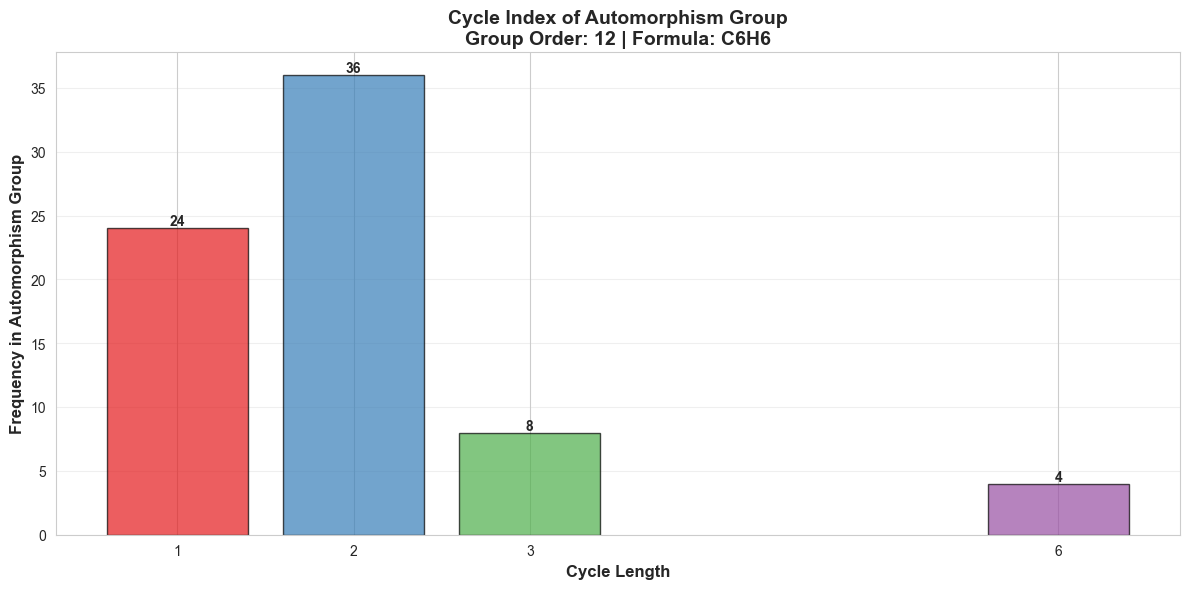

In [4]:
vis = IsotopomerVisualizer(benzene)

cycle_fig = vis.plot_cycle_index()
cycle_fig.savefig(str(output_dir / "benzene_cycles.png"), dpi=150, bbox_inches='tight')
plt.show()

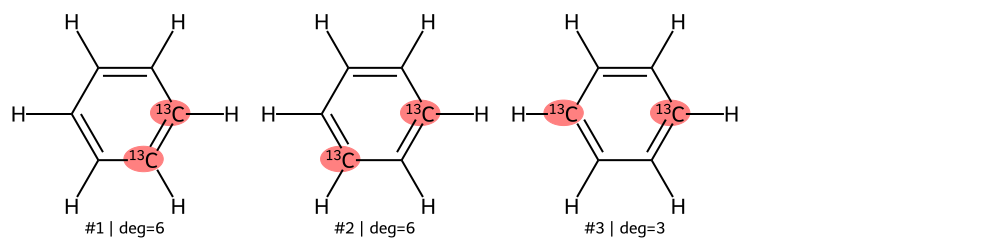

In [5]:
mol_img = vis.visualize_isotopomers(results)
mol_img.save(str(output_dir / "benzene_structures.png"), "PNG")
mol_img

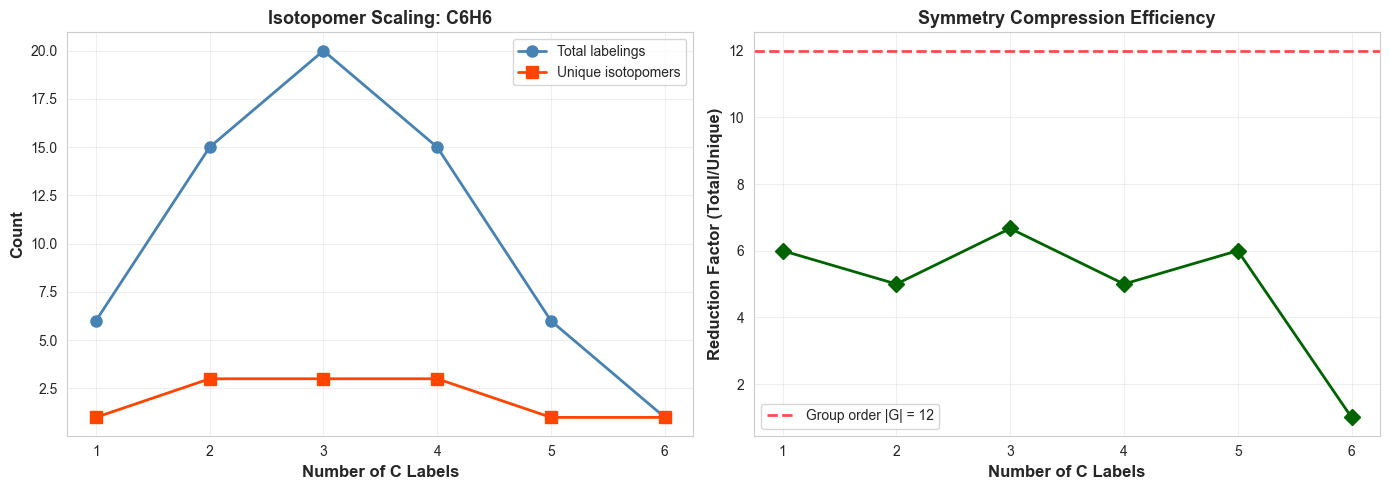

In [6]:
# Benzene symmetry reduction scaling
vis = IsotopomerVisualizer(benzene)

scaling_fig = vis.plot_symmetry_reduction_scaling('C', max_labels=6)
scaling_fig.savefig(str(output_dir / "benzene_scaling.png"), dpi=150, bbox_inches='tight')
plt.show()

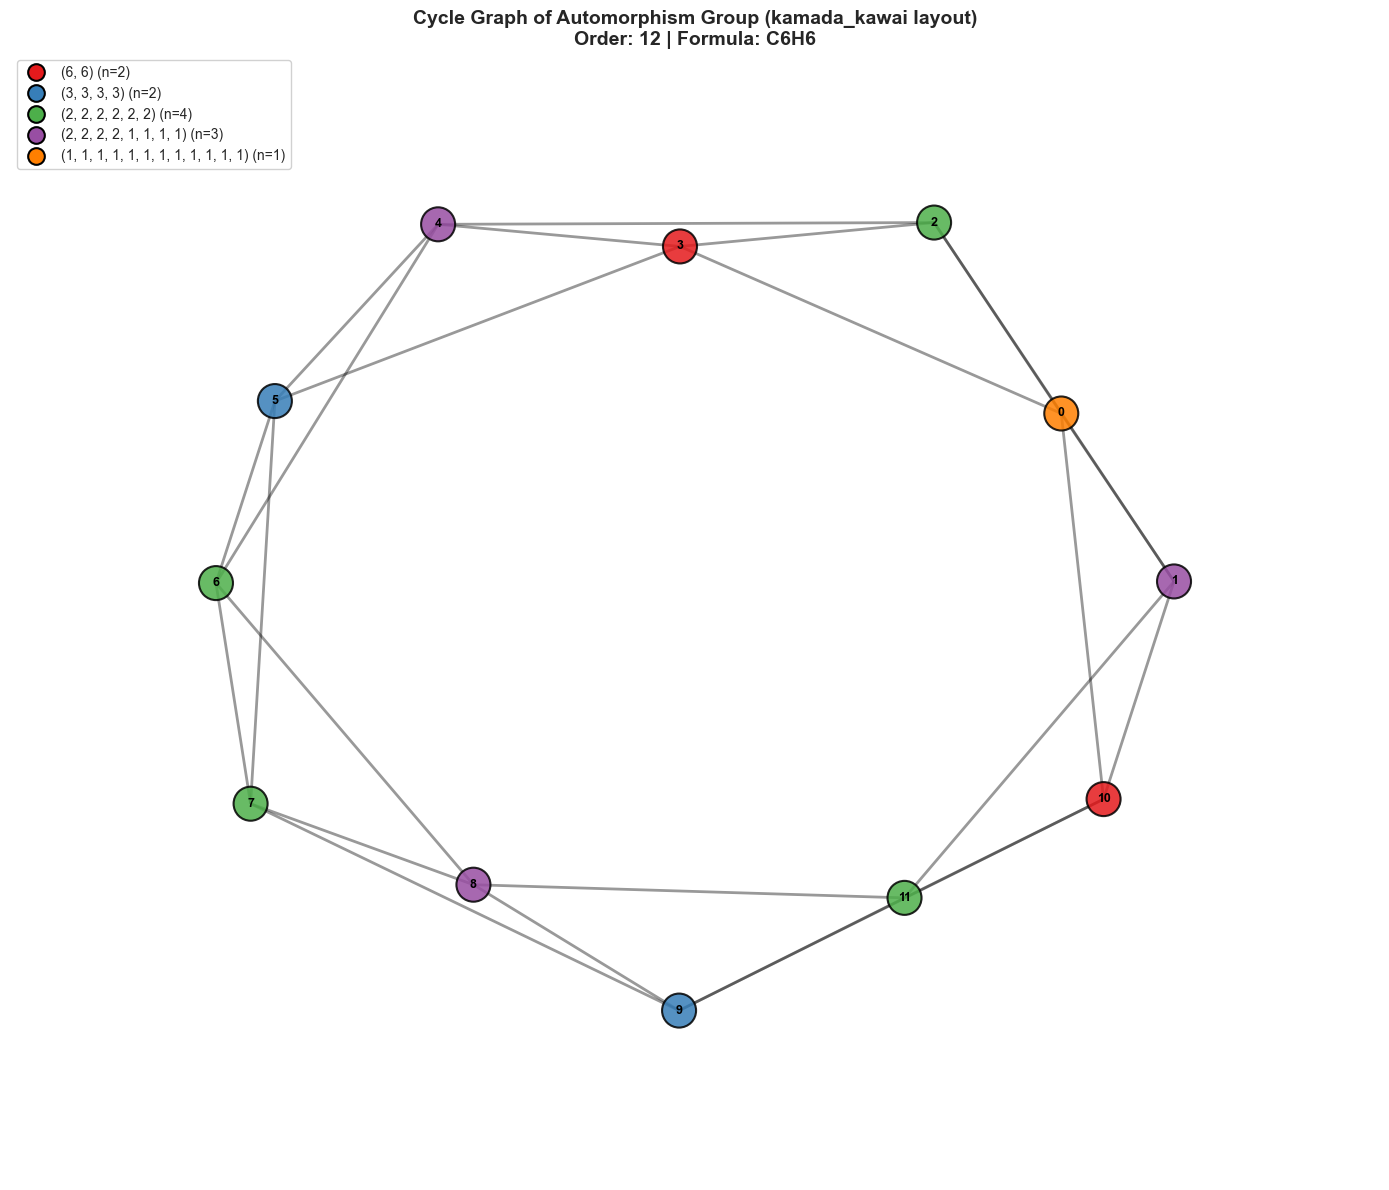

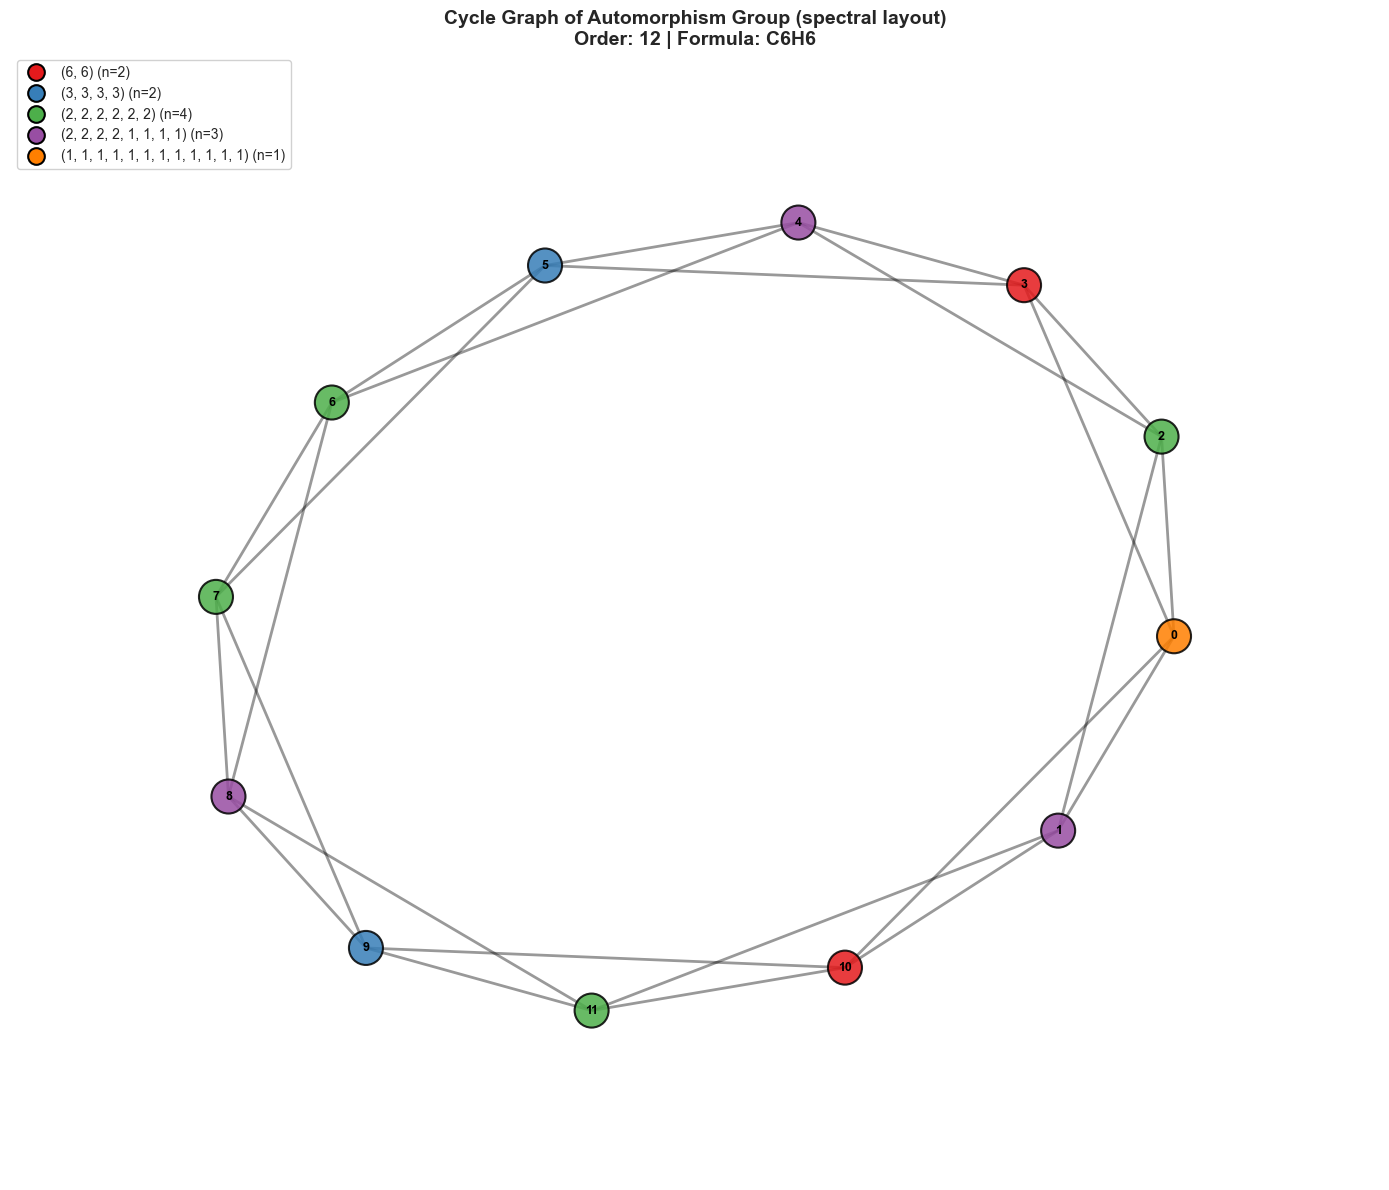

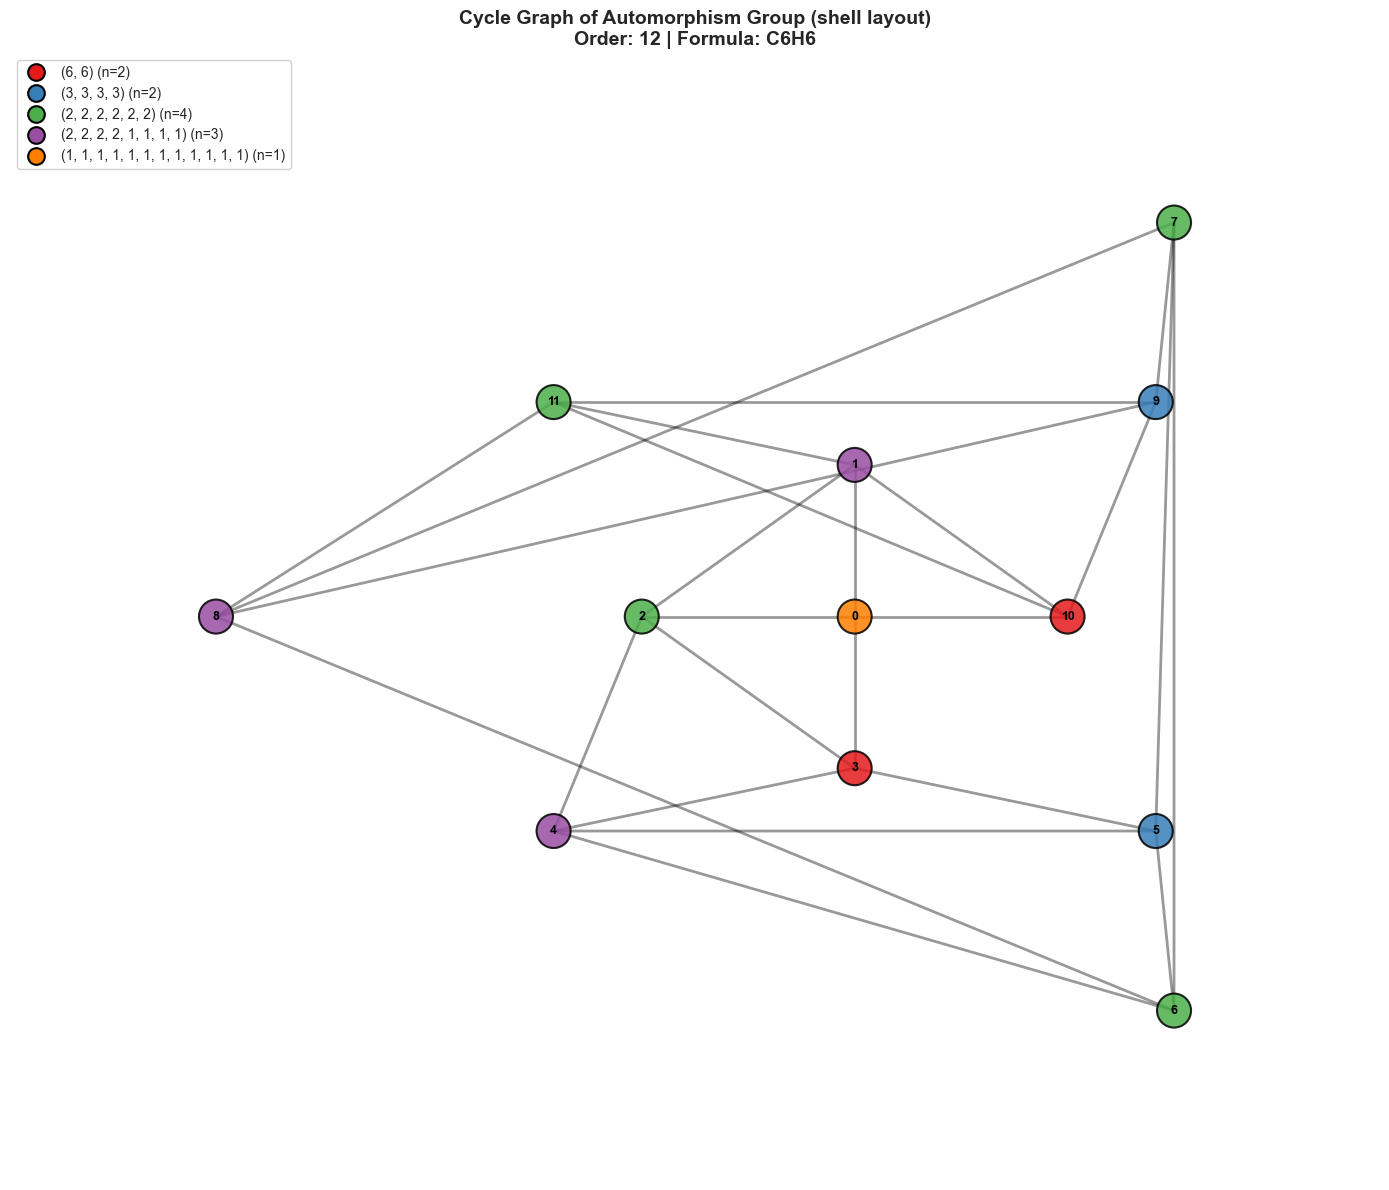

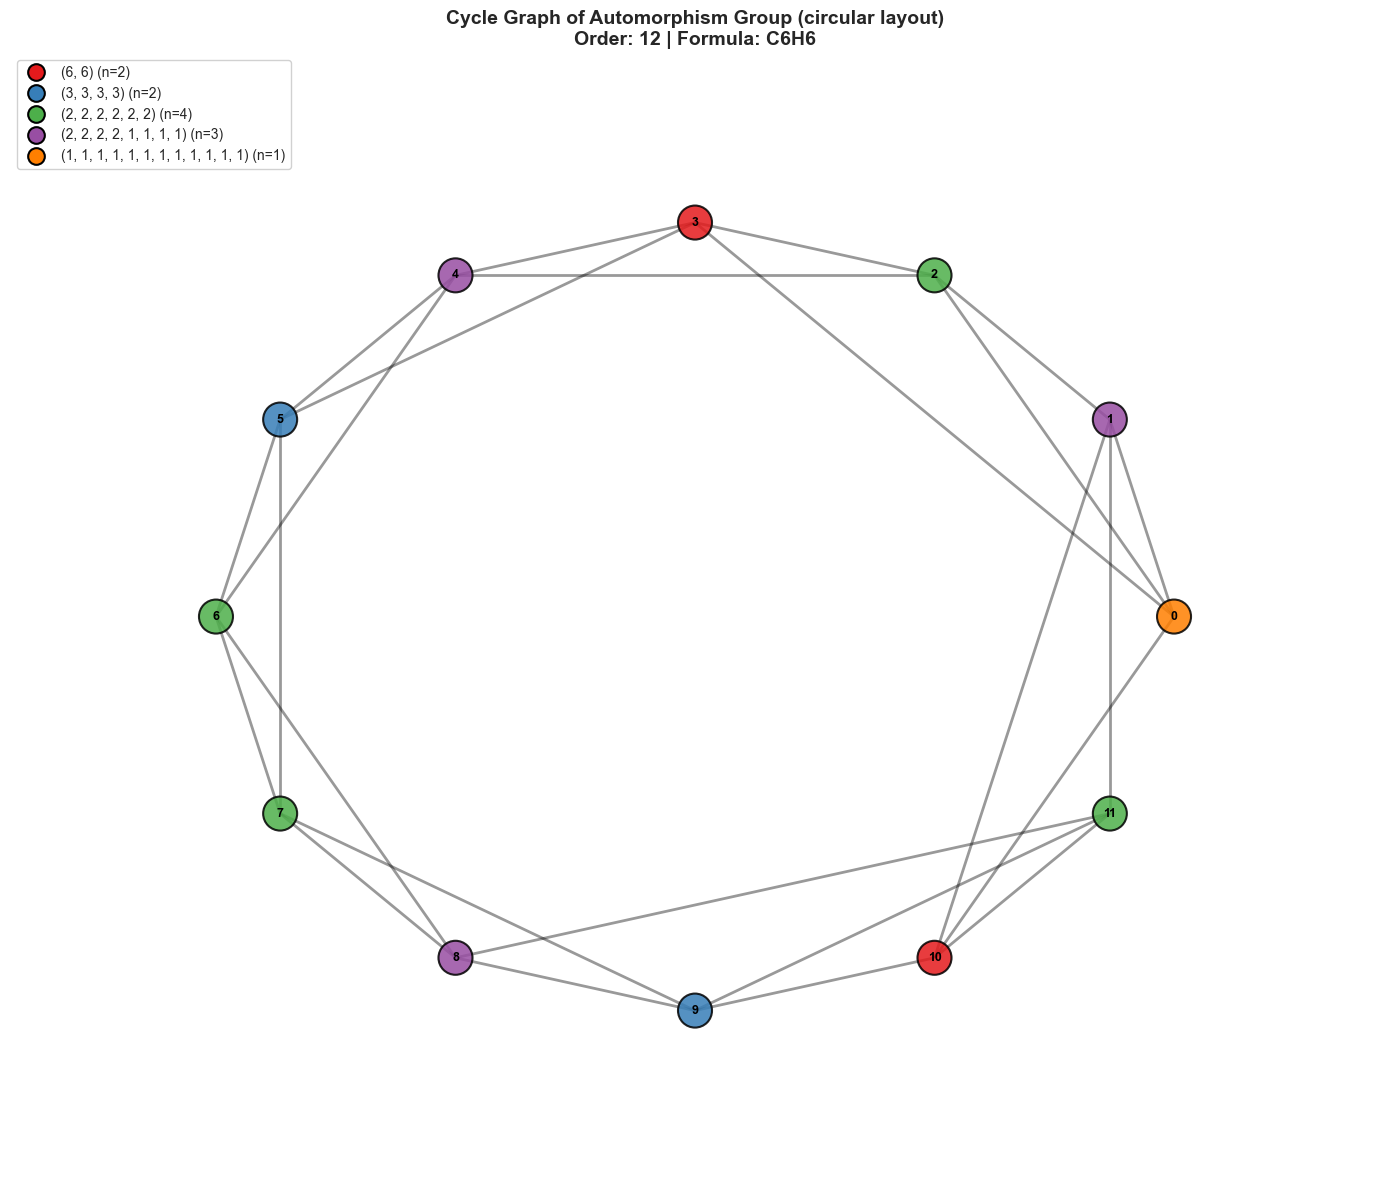

In [7]:
# Kamada-Kawai: best for minimizing edge lengths
fig1 = vis.plot_cycle_graph(layout='kamada_kawai')
fig1.savefig('cycle_graph_kk.png', dpi=150, bbox_inches='tight')

# Spectral: deterministic, good spacing
fig2 = vis.plot_cycle_graph(layout='spectral')
fig2.savefig('cycle_graph_spectral.png', dpi=150, bbox_inches='tight')

# Shell: concentric by distance from identity
fig3 = vis.plot_cycle_graph(layout='shell')
fig3.savefig('cycle_graph_shell.png', dpi=150, bbox_inches='tight')

# Circular: for cyclic/dihedral groups
fig4 = vis.plot_cycle_graph(layout='circular')
fig4.savefig('cycle_graph_circular.png', dpi=150, bbox_inches='tight')

In [ ]:
inchi_data = generate_inchi_data(benzene, {"C": 2})

print(inchi_data.get_summary())
print("\nInChI to labeling mapping (showing degeneracies):")
for inchi, labelings in inchi_data.inchi_to_labelings.items():
    print(f"InChI: {inchi}")
    print(f"Degeneracy: {len(labelings)}")
    print(f"Labelings: {labelings}")
    print()

This function performs three checks:
1. Number of orbits (Burnside) equals number of unique InChIs
2. Sum of orbit degeneracies equals total combinatorial count
3. Each orbit produces exactly one unique InChI

In [ ]:
results = benzene.enumerate_isotopomers({"C": 2})

validation = verify_orbit_partition(benzene, results, {"C": 2})

print(f"Validation passed: {validation['valid']}")
print(f"\nNumber of orbits (Burnside): {validation['num_orbits']}")
print(f"Number of unique InChIs: {validation['num_unique_inchis']}")
print(f"Total combinatorial labelings: {validation['total_labelings']}")
print(f"Sum of degeneracies: {validation['degeneracy_sum']}")

if validation['errors']:
    print("\nERRORS:")
    for error in validation['errors']:
        print(f"  - {error}")

print("\nDegeneracies from InChI enumeration:")
for inchi, deg in validation['inchi_degeneracies'].items():
    print(f"  {deg} labelings produce this InChI")

## Acetate Analysis

In [7]:
acetate = IsotopomerEnumerator("CC(=O)O", "smiles")

print(f"Formula: {acetate.get_formula()}")
print(f"Symmetry group order: {acetate.get_symmetry_group_size()}")

Formula: C2H4O2
Symmetry group order: 6


In [8]:
results_1c = acetate.enumerate_isotopomers({"C": 1})

print(f"1 13C: {len(results_1c)} unique isotopomers")
for r in results_1c:
    print(f"  #{r.isotopomer_id}: atoms {r.atom_indices}, deg={r.degeneracy}")

1 13C: 2 unique isotopomers
  #0: atoms (0,), deg=1
  #1: atoms (1,), deg=1


In [9]:
results_1c2h = acetate.enumerate_isotopomers({"C": 1, "H": 2})

print(f"1 13C + 2 2H: {len(results_1c2h)} unique isotopomers")
print(f"Total labelings: {sum(r.degeneracy for r in results_1c2h)}")

for r in results_1c2h:
    print(f"  #{r.isotopomer_id}: atoms {r.atom_indices}, deg={r.degeneracy}")

1 13C + 2 2H: 4 unique isotopomers
Total labelings: 12
  #0: atoms (0, 4, 5), deg=3
  #1: atoms (0, 4, 7), deg=3
  #2: atoms (1, 4, 5), deg=3
  #3: atoms (1, 4, 7), deg=3


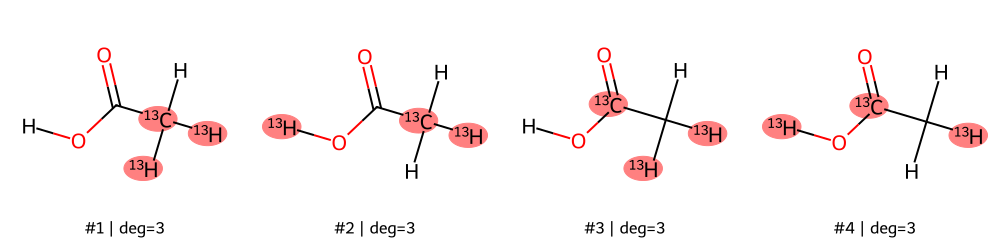

In [10]:
vis = IsotopomerVisualizer(acetate)

mol_img = vis.visualize_isotopomers(results_1c2h)
mol_img.save(str(output_dir / "acetate_1c2h.png"), "PNG")
mol_img

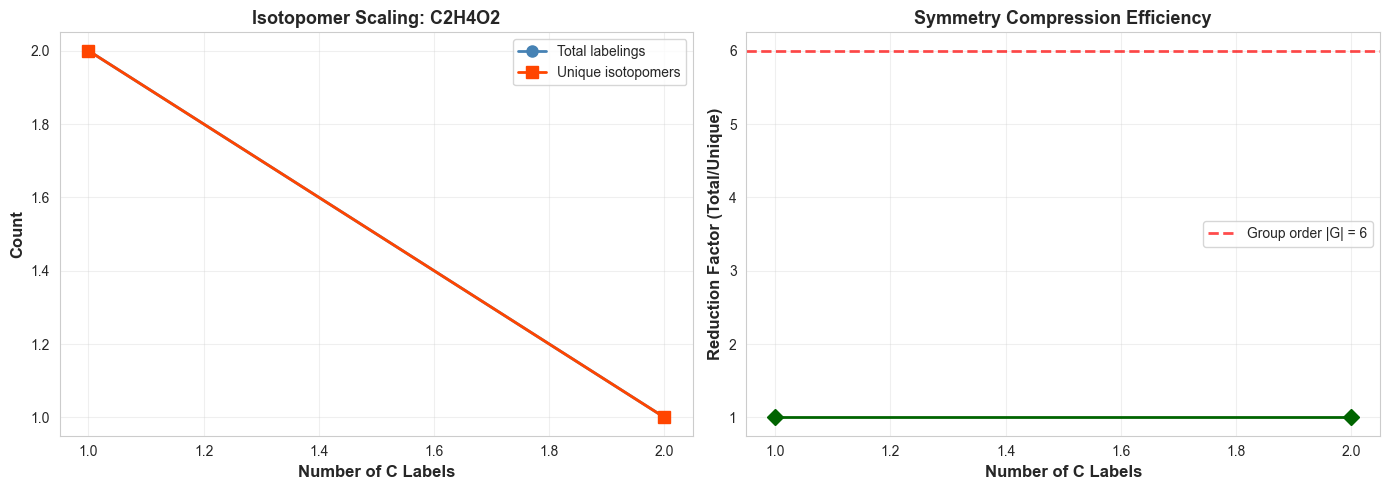

In [11]:
# Acetate symmetry reduction scaling - Carbon
scaling_fig = vis.plot_symmetry_reduction_scaling('C', max_labels=2)
scaling_fig.savefig(str(output_dir / "acetate_scaling_carbon.png"), dpi=150, bbox_inches='tight')
plt.show()

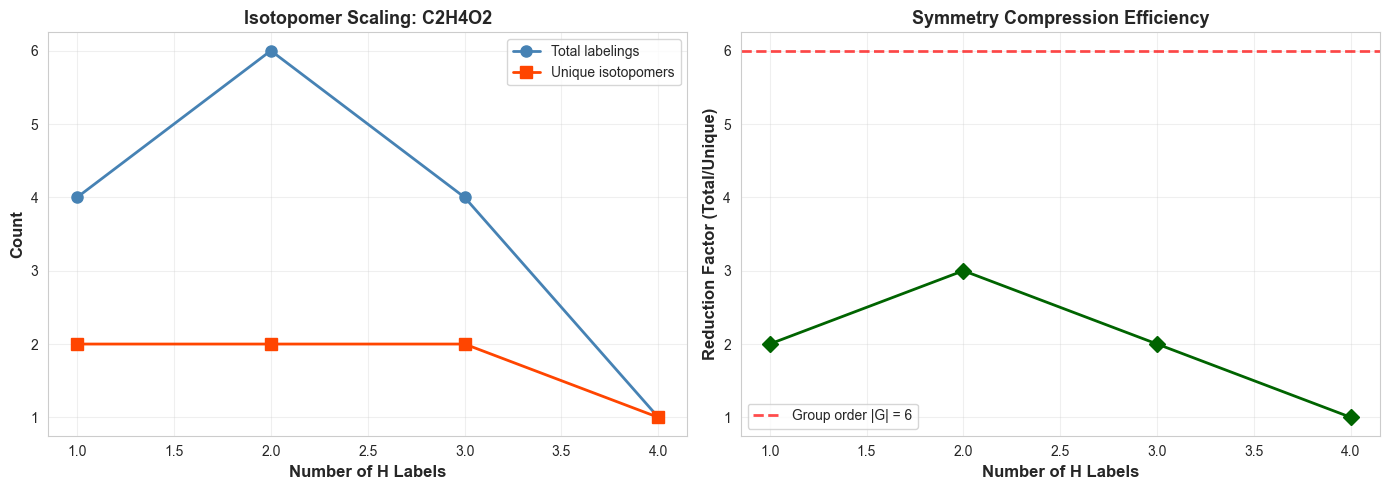

In [12]:
# Acetate symmetry reduction scaling - Hydrogen
scaling_fig = vis.plot_symmetry_reduction_scaling('H', max_labels=4)
scaling_fig.savefig(str(output_dir / "acetate_scaling_hydrogen.png"), dpi=150, bbox_inches='tight')
plt.show()

Demonstrates multi-element labeling comparison to InChI results

In [ ]:
inchi_data_multi = generate_inchi_data(acetate, {"C": 1, "H": 2})

print(inchi_data_multi.get_summary())
print(f"InChI unique isotopomers: {inchi_data_multi.unique_orbits}")
print(f"Burnside unique orbits: {len(results_1c2h)}")

## Ethanol Analysis

In [13]:
ethanol = IsotopomerEnumerator("CCO", "smiles")

print(f"Formula: {ethanol.get_formula()}")
print(f"Symmetry group order: {ethanol.get_symmetry_group_size()}")

Formula: C2H6O
Symmetry group order: 12


In [14]:
results_1c = ethanol.enumerate_isotopomers({"C": 1})

print(f"1 13C: {len(results_1c)} unique isotopomers")
for r in results_1c:
    print(f"  #{r.isotopomer_id}: atoms {r.atom_indices}, deg={r.degeneracy}")

1 13C: 2 unique isotopomers
  #0: atoms (0,), deg=1
  #1: atoms (1,), deg=1


In [15]:
results_2h = ethanol.enumerate_isotopomers({"H": 2})

print(f"2 2H: {len(results_2h)} unique isotopomers")
for r in results_2h:
    print(f"  #{r.isotopomer_id}: atoms {r.atom_indices}, deg={r.degeneracy}")

2 2H: 5 unique isotopomers
  #0: atoms (3, 4), deg=3
  #1: atoms (3, 6), deg=6
  #2: atoms (3, 8), deg=3
  #3: atoms (6, 7), deg=1
  #4: atoms (6, 8), deg=2


[22:06:31] WARNING: Omitted undefined stereo

[22:06:31] WARNING: Omitted undefined stereo



In [16]:
results_1c2h = ethanol.enumerate_isotopomers({"C": 1, "H": 2})

print(f"1 13C + 2 2H: {len(results_1c2h)} unique isotopomers")
print(f"Total labelings: {sum(r.degeneracy for r in results_1c2h)}")

1 13C + 2 2H: 10 unique isotopomers
Total labelings: 30


[22:06:31] WARNING: Omitted undefined stereo

[22:06:31] WARNING: Omitted undefined stereo

[22:06:31] WARNING: Omitted undefined stereo

[22:06:31] WARNING: Omitted undefined stereo



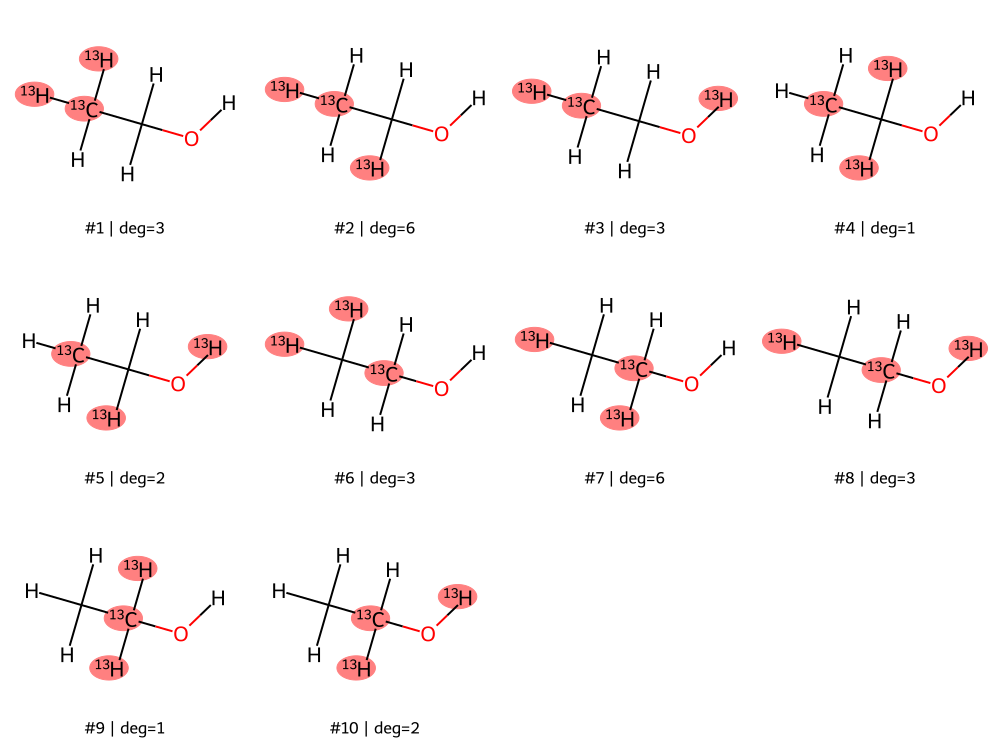

In [17]:
vis = IsotopomerVisualizer(ethanol)

mol_img = vis.visualize_isotopomers(results_1c2h)
mol_img.save(str(output_dir / "ethanol_1c2h.png"), "PNG")
mol_img

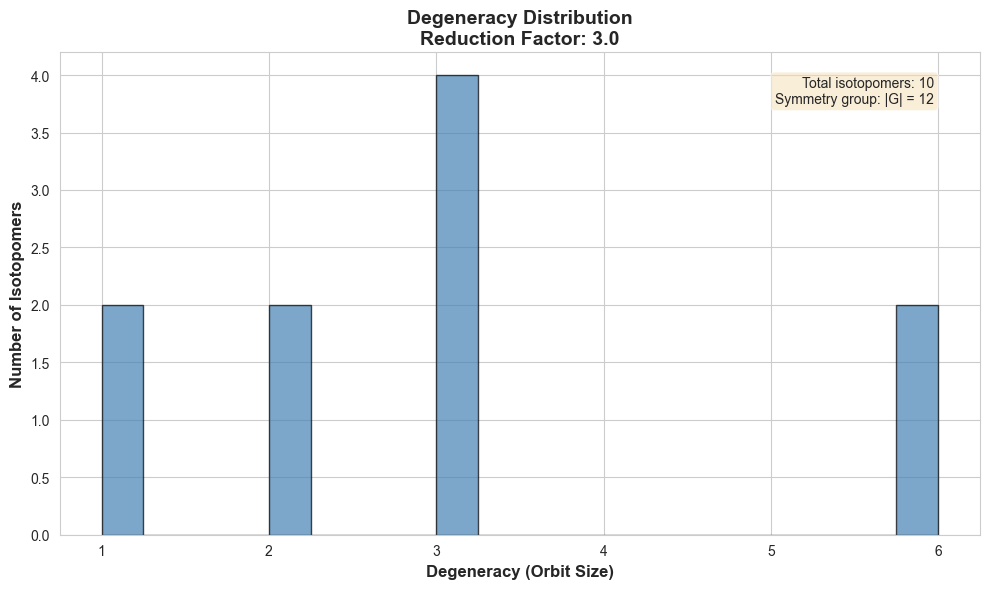

In [18]:
degen_fig = vis.plot_degeneracy_histogram(results_1c2h)
degen_fig.savefig(str(output_dir / "ethanol_degeneracy.png"), dpi=150, bbox_inches='tight')
plt.show()

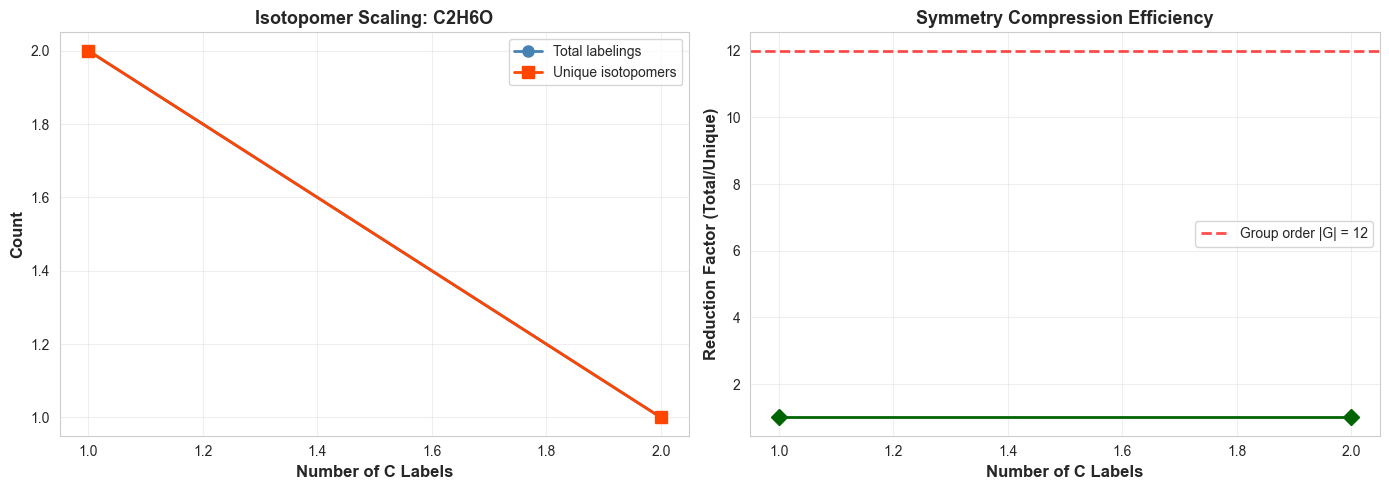

In [19]:
# Ethanol symmetry reduction scaling - Carbon
scaling_fig = vis.plot_symmetry_reduction_scaling('C', max_labels=2)
scaling_fig.savefig(str(output_dir / "ethanol_scaling_carbon.png"), dpi=150, bbox_inches='tight')
plt.show()

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo



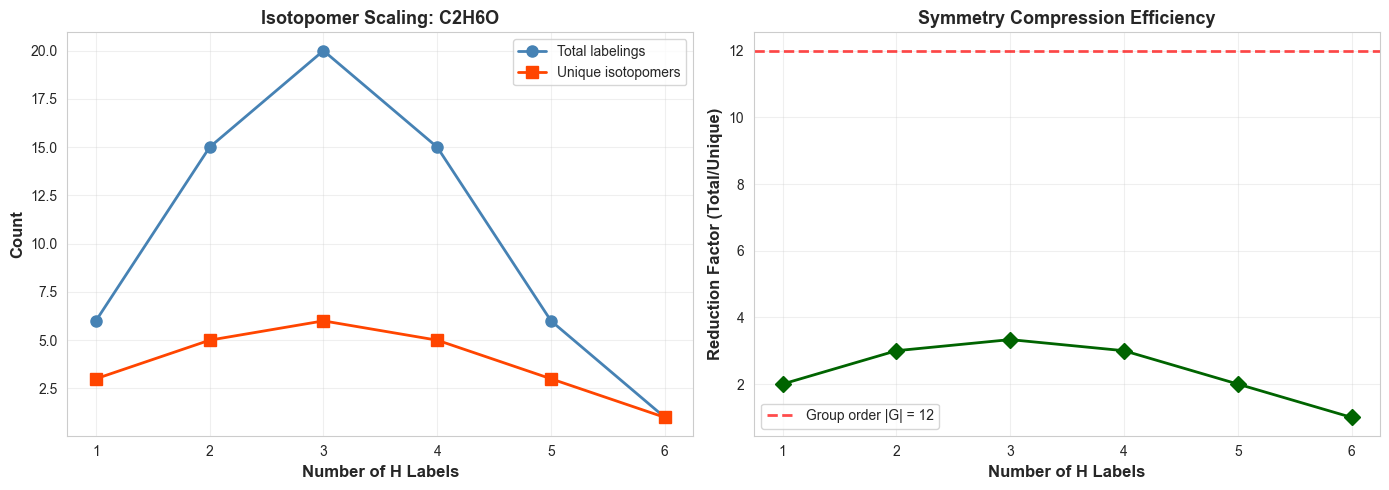

In [20]:
# Ethanol symmetry reduction scaling - Hydrogen
scaling_fig = vis.plot_symmetry_reduction_scaling('H', max_labels=6)
scaling_fig.savefig(str(output_dir / "ethanol_scaling_hydrogen.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cubane Analysis

In [21]:
cubane = IsotopomerEnumerator("C12C3C4C1C5C4C3C25", "smiles")

print(f"Formula: {cubane.get_formula()}")
print(f"Symmetry group order: {cubane.get_symmetry_group_size()}")
print(f"Carbon atoms: {cubane.get_num_atoms('C')}")
print(f"Hydrogen atoms: {cubane.get_num_atoms('H')}")

Formula: C8H8
Symmetry group order: 48
Carbon atoms: 8
Hydrogen atoms: 8


In [22]:
results_1c = cubane.enumerate_isotopomers({"C": 1})

print(f"1 13C: {len(results_1c)} unique isotopomers")
for r in results_1c:
    print(f"  #{r.isotopomer_id}: atoms {r.atom_indices}, deg={r.degeneracy}")

1 13C: 1 unique isotopomers
  #0: atoms (0,), deg=8


[22:06:32] WARNING: Omitted undefined stereo



In [23]:
results_2c = cubane.enumerate_isotopomers({"C": 2})

print(f"2 13C: {len(results_2c)} unique isotopomers")
for r in results_2c:
    print(f"  #{r.isotopomer_id}: atoms {r.atom_indices}, deg={r.degeneracy}")

2 13C: 3 unique isotopomers
  #0: atoms (0, 1), deg=12
  #1: atoms (0, 2), deg=12
  #2: atoms (0, 5), deg=4


[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo



In [24]:
results_2c2h = cubane.enumerate_isotopomers({"C": 2, "H": 2})

print(f"2 13C + 2 2H: {len(results_2c2h)} unique isotopomers")
print(f"Total labelings: {sum(r.degeneracy for r in results_2c2h)}")

2 13C + 2 2H: 29 unique isotopomers
Total labelings: 784


[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefined stereo

[22:06:32] WARNING: Omitted undefi

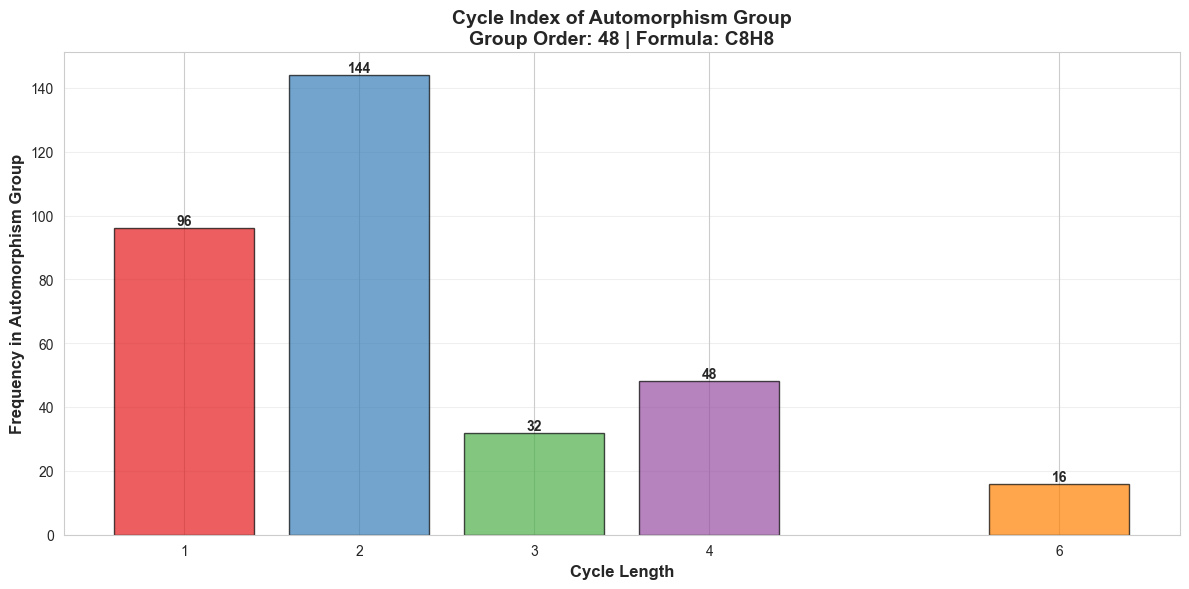

In [25]:
vis = IsotopomerVisualizer(cubane)

cycle_fig = vis.plot_cycle_index()
cycle_fig.savefig(str(output_dir / "cubane_cycles.png"), dpi=150, bbox_inches='tight')
plt.show()

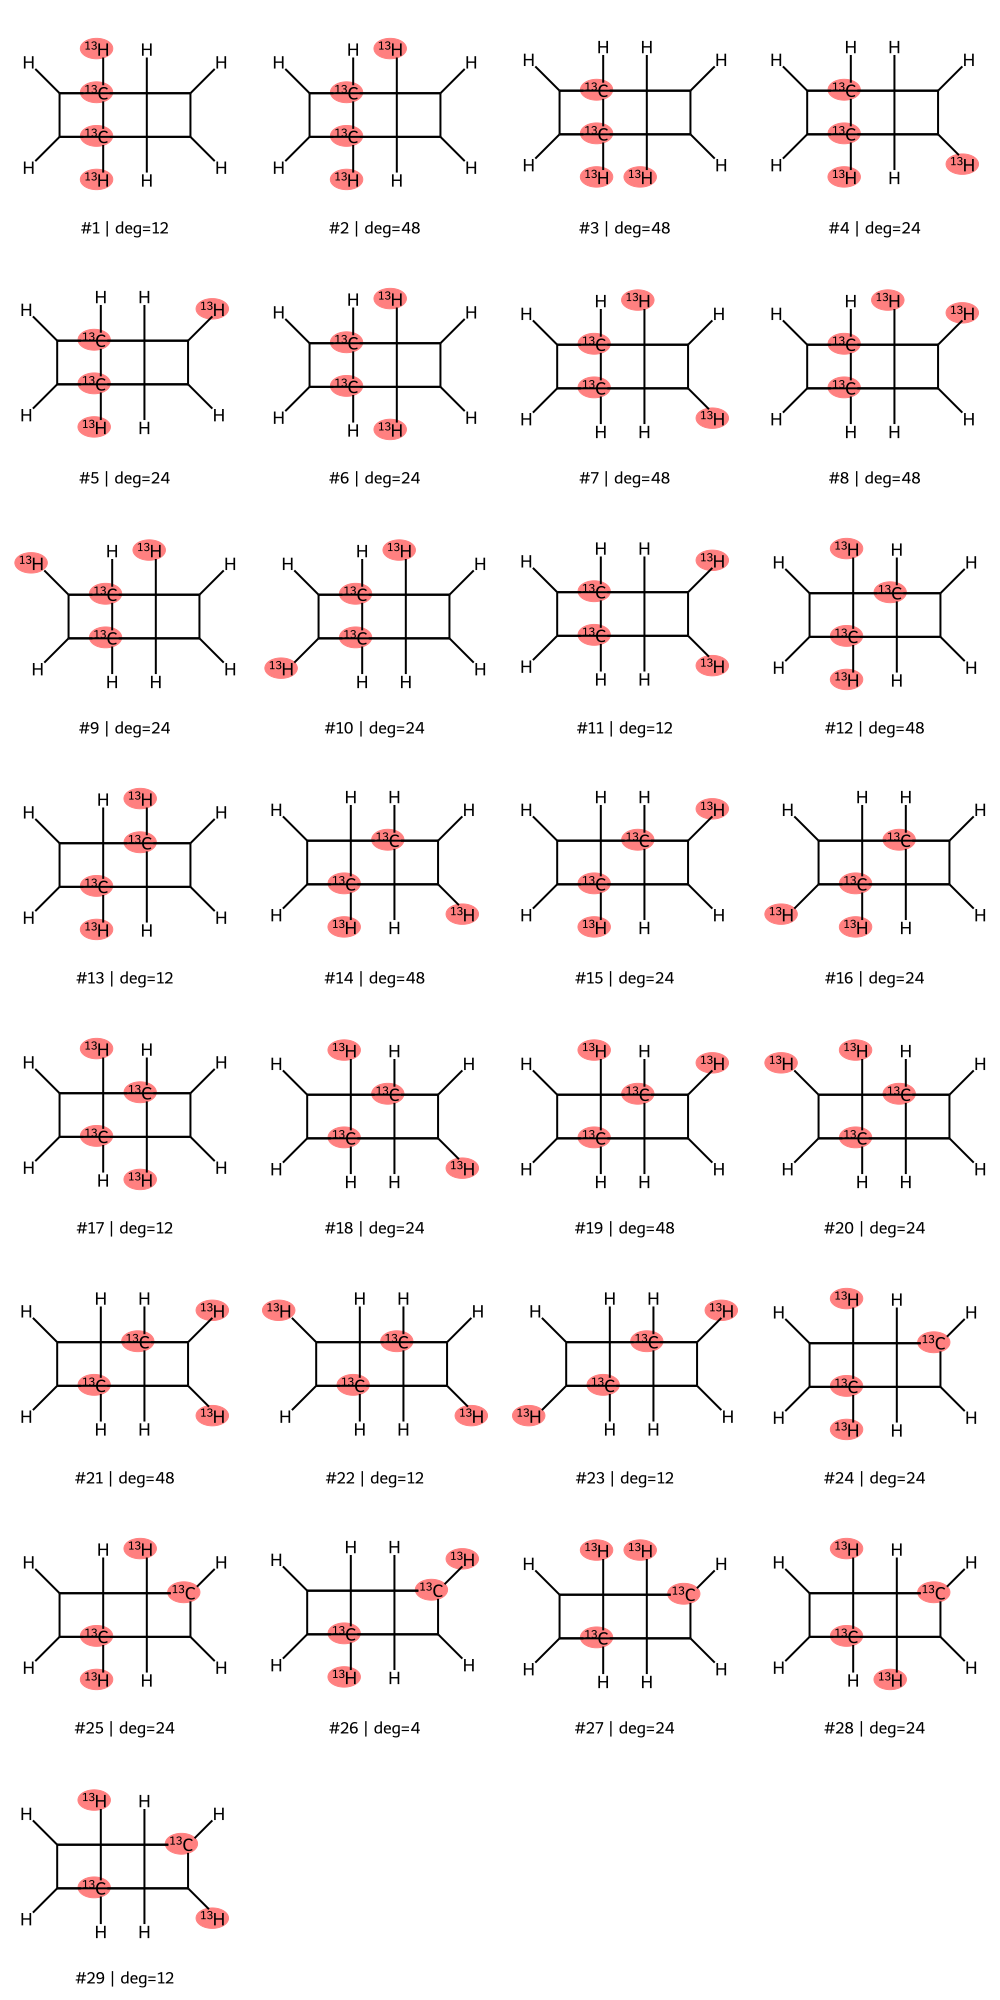

In [35]:
mol_img = vis.visualize_isotopomers(results_2c2h, max_show=32)
mol_img.save(str(output_dir / "cubane_2c2h.png"), "PNG")
mol_img

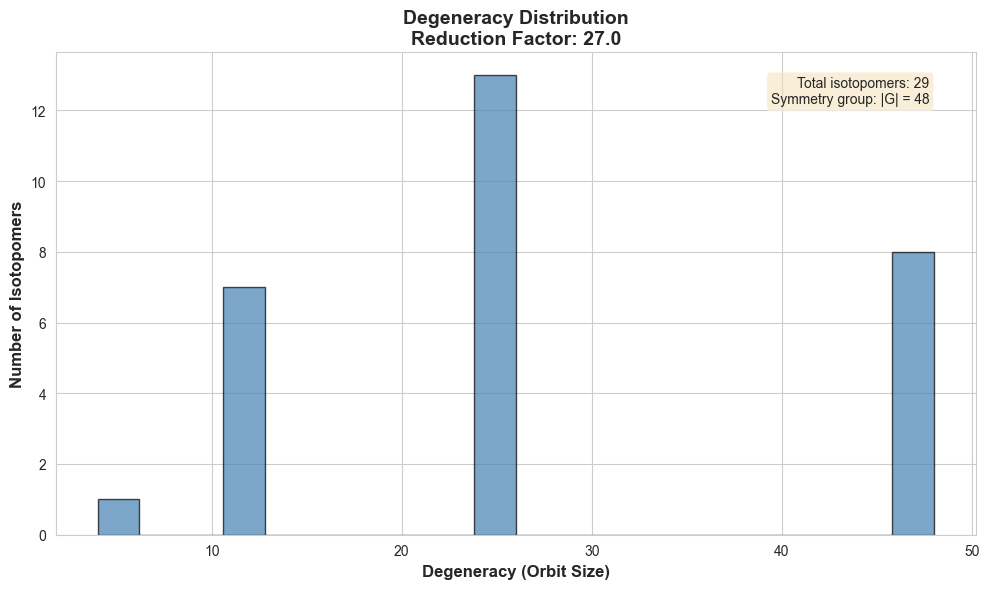

In [27]:
degen_fig = vis.plot_degeneracy_histogram(results_2c2h)
degen_fig.savefig(str(output_dir / "cubane_degeneracy.png"), dpi=150, bbox_inches='tight')
plt.show()

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo

[22:06:33] WARNING: Omitted undefined stereo



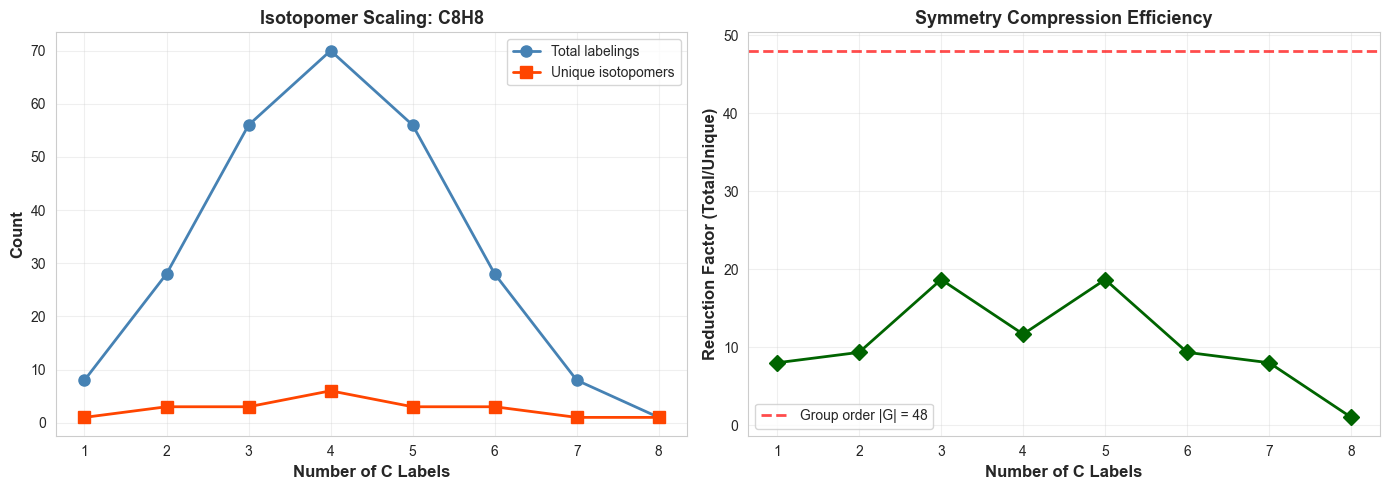

In [28]:
# Cubane symmetry reduction scaling - Carbon
scaling_fig = vis.plot_symmetry_reduction_scaling('C', max_labels=8)
scaling_fig.savefig(str(output_dir / "cubane_scaling_carbon.png"), dpi=150, bbox_inches='tight')
plt.show()

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo



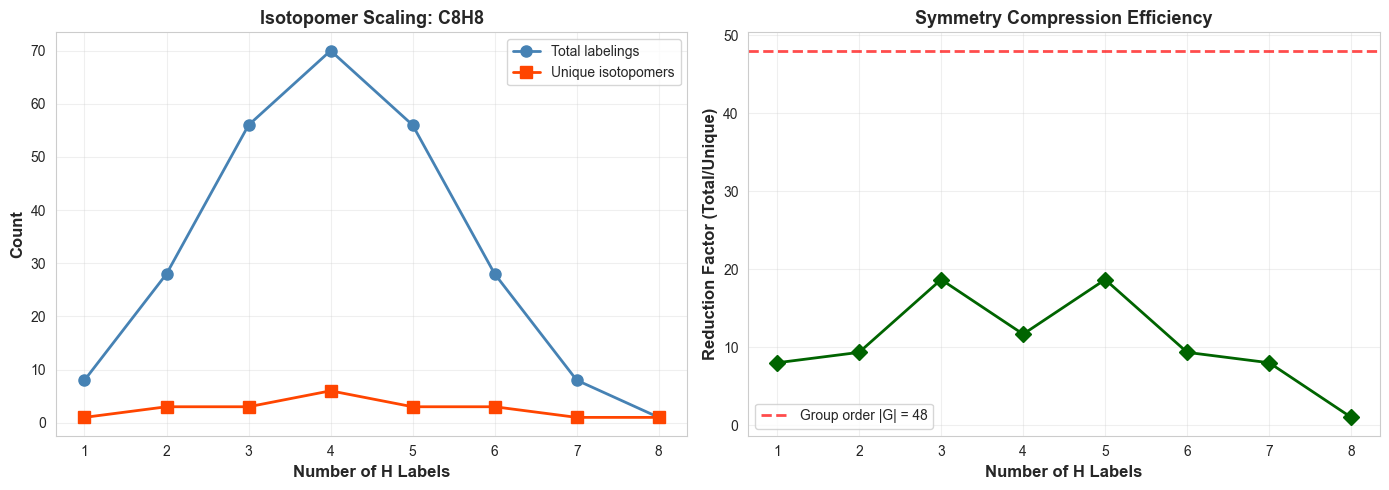

In [29]:
# Cubane symmetry reduction scaling - Hydrogen
scaling_fig = vis.plot_symmetry_reduction_scaling('H', max_labels=8)
scaling_fig.savefig(str(output_dir / "cubane_scaling_hydrogen.png"), dpi=150, bbox_inches='tight')
plt.show()

## InChI comparison

In [ ]:
molecules = {
    "Ethanol": ("CCO", {"C": 1}),
    "Benzene": ("c1ccccc1", {"C": 2}),
    "Acetate": ("CC(=O)O", {"C": 1, "H": 2}),
    "Cubane": ("C12C3C4C1C5C4C3C25", {"C": 2})
}

comparison_results = []

for name, (smiles, label_spec) in molecules.items():
    enumerator = IsotopomerEnumerator(smiles, "smiles")
    inchi_data = generate_inchi_data(enumerator, label_spec)
    
    comparison_results.append({
        "Molecule": name,
        "Symmetry_Group_Order": enumerator.get_symmetry_group_size(),
        "Total_Labelings": inchi_data.total_labelings,
        "Unique_Orbits": inchi_data.unique_orbits,
        "Unique_InChIs": inchi_data.unique_inchis,
        "Comparison": "PASS" if inchi_data.comparison_passed else "FAIL",
        "Reduction_Factor": inchi_data.total_labelings / inchi_data.unique_orbits
    })

df = pd.DataFrame(comparison_results)
print("\nValidation Summary Across Molecules:")
print("="*80)
print(df.to_string(index=False))

# Save to CSV
df.to_csv(output_dir / "validation_summary.csv", index=False)

## Systematic cubane enumeration

In [30]:
import pandas as pd
import numpy as np

cubane = IsotopomerEnumerator("C12C3C4C1C5C4C3C25", "smiles")

data = []

for n_c in range(1, 5):
    results = cubane.enumerate_isotopomers({"C": n_c})
    data.append({
        "C_labels": n_c,
        "H_labels": 0,
        "unique": len(results),
        "total": sum(r.degeneracy for r in results)
    })

for n_h in range(1, 5):
    results = cubane.enumerate_isotopomers({"H": n_h})
    data.append({
        "C_labels": 0,
        "H_labels": n_h,
        "unique": len(results),
        "total": sum(r.degeneracy for r in results)
    })

for n_c in range(1, 5):
    for n_h in range(1, 5):
        results = cubane.enumerate_isotopomers({"C": n_c, "H": n_h})
        data.append({
            "C_labels": n_c,
            "H_labels": n_h,
            "unique": len(results),
            "total": sum(r.degeneracy for r in results)
        })

df = pd.DataFrame(data)
df["reduction"] = df["total"] / df["unique"]

df

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefined stereo

[22:06:34] WARNING: Omitted undefi

,C_labels,H_labels,unique,total,reduction
0,1,0,1,8,8.000000
1,2,0,3,28,9.333333
2,3,0,3,56,18.666667
3,4,0,6,70,11.666667
4,0,1,1,8,8.000000
5,0,2,3,28,9.333333
6,0,3,3,56,18.666667
7,0,4,6,70,11.666667
8,1,1,4,64,16.000000
9,1,2,9,224,24.888889


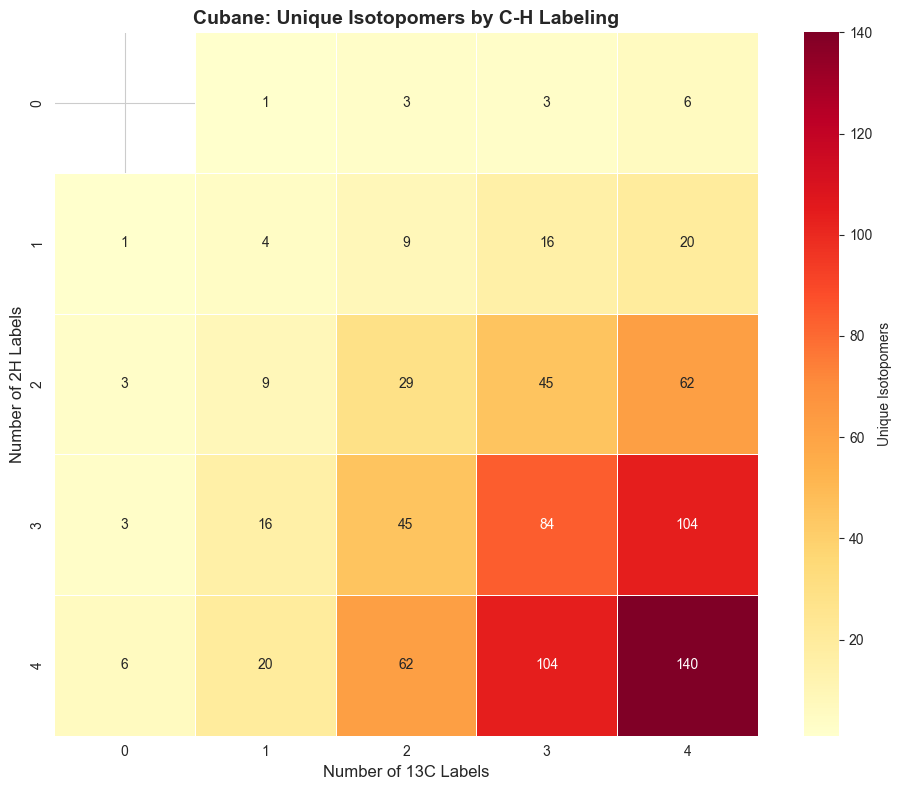

In [31]:
import seaborn as sns

pivot_unique = df.pivot_table(
    values='unique',
    index='H_labels',
    columns='C_labels',
    fill_value=np.nan
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_unique, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': 'Unique Isotopomers'},
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Cubane: Unique Isotopomers by C-H Labeling', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of 13C Labels', fontsize=12)
ax.set_ylabel('Number of 2H Labels', fontsize=12)
plt.tight_layout()
plt.savefig(str(output_dir / "cubane_heatmap_unique.png"), dpi=300, bbox_inches='tight')
plt.show()

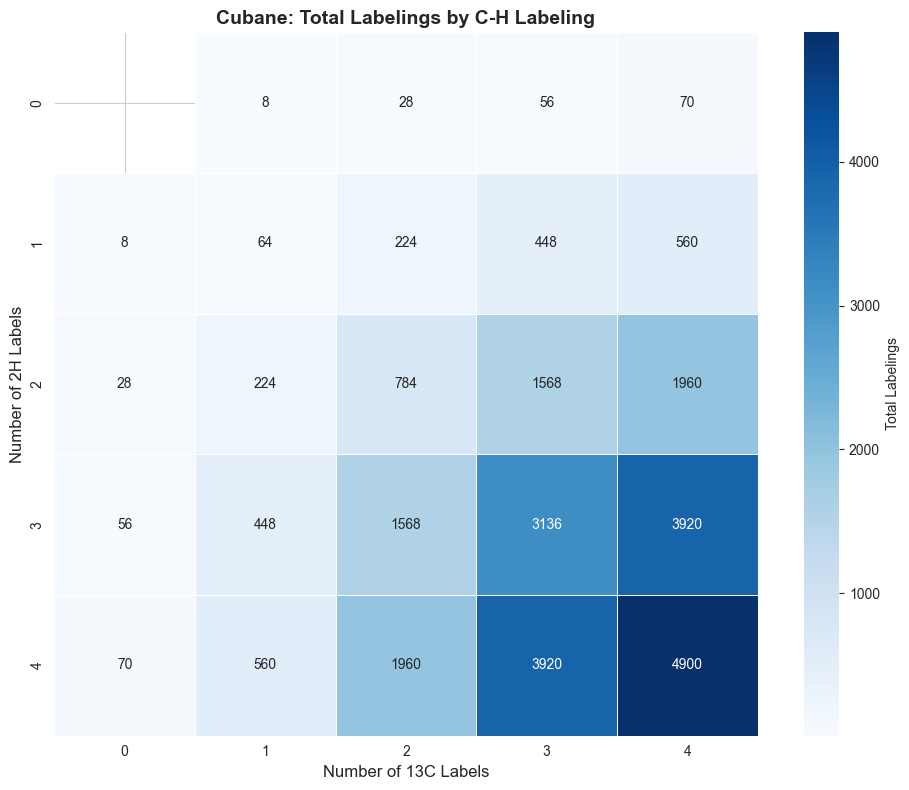

In [32]:
pivot_total = df.pivot_table(
    values='total',
    index='H_labels',
    columns='C_labels',
    fill_value=np.nan
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_total, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': 'Total Labelings'},
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Cubane: Total Labelings by C-H Labeling', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of 13C Labels', fontsize=12)
ax.set_ylabel('Number of 2H Labels', fontsize=12)
plt.tight_layout()
plt.savefig(str(output_dir / "cubane_heatmap_total.png"), dpi=300, bbox_inches='tight')
plt.show()

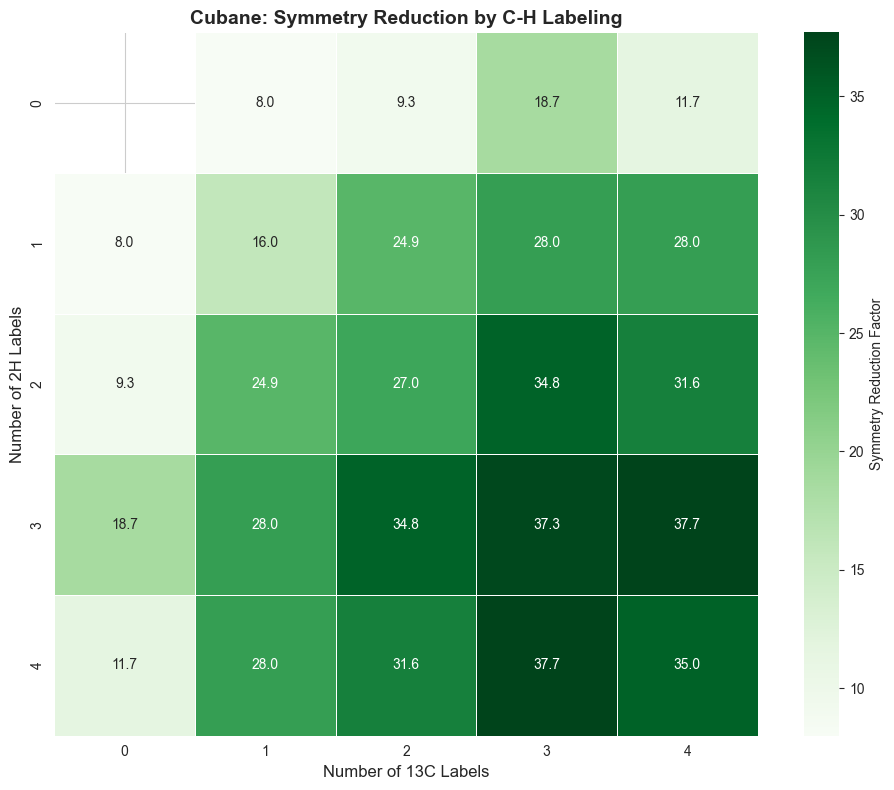

In [33]:
pivot_reduction = df.pivot_table(
    values='reduction',
    index='H_labels',
    columns='C_labels',
    fill_value=np.nan
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_reduction, annot=True, fmt='.1f', cmap='Greens',
            cbar_kws={'label': 'Symmetry Reduction Factor'},
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Cubane: Symmetry Reduction by C-H Labeling', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of 13C Labels', fontsize=12)
ax.set_ylabel('Number of 2H Labels', fontsize=12)
plt.tight_layout()
plt.savefig(str(output_dir / "cubane_heatmap_reduction.png"), dpi=300, bbox_inches='tight')
plt.show()

In [34]:
df.to_csv(str(output_dir / "cubane_systematic.csv"), index=False)
print(f"Results saved to {output_dir}")

Results saved to outputs
